In [5]:
import pandas as pd

df = pd.read_csv("../data/model_ready_generic.csv")
df.head()



,item_id,food_type,cooked_at,storage_temperature_c,temperature_duration_hours,expiry_type,expiry_date,ingredient_text,validation_errors,hours_since_prepared,is_use_by,has_temperature_data
0,G001,Cooked Rice,2025-12-05 08:30:00,4.1,18,use_by,2025-12-07,"Rice, salt, oil",NaN,-10268.50,1,1
1,G002,Chicken Curry,2025-12-05 12:00:00,5.2,10,use_by,2025-12-08,"Chicken, spices, yoghurt",NaN,-10272.00,1,1
2,G004,Milk Pack,2025-12-06 09:00:00,3.8,36,use_by,2025-12-11,Milk,NaN,-10293.00,1,1
3,G006,Pasta Salad,2025-12-07 14:15:00,4.5,6,use_by,2025-12-09,"Pasta, mayo, peas, carrots",NaN,-10322.25,1,1
4,G007,Beef Stew,2025-12-03 18:00:00,3.9,48,use_by,2025-12-06,"Beef, potatoes, broth, onions",NaN,-10230.00,1,1


In [6]:
df.shape, df.columns.tolist()

((105, 12),
 ['item_id',
  'food_type',
  'cooked_at',
  'storage_temperature_c',
  'temperature_duration_hours',
  'expiry_type',
  'expiry_date',
  'ingredient_text',
  'validation_errors',
  'hours_since_prepared',
  'is_use_by',
  'has_temperature_data'])

In [7]:
import numpy as np

def compute_freshness_risk(row):
    risk = 0.0

    # Time decay (soft limit: 72 hours)
    if pd.notna(row["hours_since_prepared"]):
        risk += min(row["hours_since_prepared"] / 72, 1.0)

    # Temperature penalty
    if row["has_temperature_data"] == 1:
        if row["storage_temperature_c"] > 8:
            risk += 0.3

    # Use-by items degrade faster
    if row["is_use_by"] == 1:
        risk += 0.2

    return min(risk, 1.0)


df["freshness_risk"] = df.apply(compute_freshness_risk, axis=1)

df[["hours_since_prepared", "freshness_risk"]].head()


,hours_since_prepared,freshness_risk
0,-10268.50,-142.418056
1,-10272.00,-142.466667
2,-10293.00,-142.758333
3,-10322.25,-143.164583
4,-10230.00,-141.883333


In [11]:
FEATURES = [
    "hours_since_prepared",
    "has_temperature_data",
    "is_use_by"
]

X = df[FEATURES].fillna(0)
y = df["freshness_risk"]

X.head(), y.head()


(   hours_since_prepared  has_temperature_data  is_use_by
 0             -10268.50                     1          1
 1             -10272.00                     1          1
 2             -10293.00                     1          1
 3             -10322.25                     1          1
 4             -10230.00                     1          1,
 0   -142.418056
 1   -142.466667
 2   -142.758333
 3   -143.164583
 4   -141.883333
 Name: freshness_risk, dtype: float64)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

X_train.shape, X_test.shape


((78, 3), (27, 3))

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)



LinearRegression()

In [15]:
from sklearn.metrics import mean_squared_error

preds = model.predict(X_test)

mean_squared_error(y_test, preds)


2.0942796180089675e-28

In [16]:
df["predicted_risk"] = model.predict(X)

# Clamp predictions to valid range
df["predicted_risk"] = df["predicted_risk"].clip(0, 1)

df["freshness_score"] = (100 * (1 - df["predicted_risk"])).clip(0, 100)

df[["predicted_risk", "freshness_score"]].head()


,predicted_risk,freshness_score
0,0.0,100.0
1,0.0,100.0
2,0.0,100.0
3,0.0,100.0
4,0.0,100.0


In [17]:
import pandas as pd

coef_df = pd.DataFrame({
    "feature": FEATURES,
    "coefficient": model.coef_
})

coef_df


,feature,coefficient
0,hours_since_prepared,0.013889
1,has_temperature_data,0.000000
2,is_use_by,0.000000


In [18]:
coef_df.sort_values("coefficient", ascending=False)


,feature,coefficient
0,hours_since_prepared,0.013889
1,has_temperature_data,0.000000
2,is_use_by,0.000000


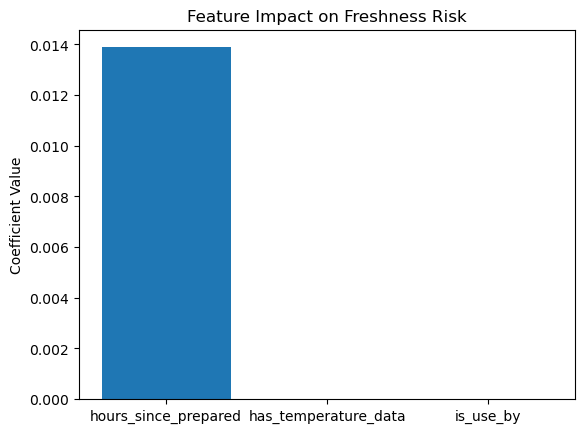

In [19]:
import matplotlib.pyplot as plt

plt.bar(coef_df["feature"], coef_df["coefficient"])
plt.ylabel("Coefficient Value")
plt.title("Feature Impact on Freshness Risk")
plt.show()


In [20]:
coef_df.to_csv("../data/model_coefficients.csv", index=False)
